# Figure 9c: Heat uptake vs. carbon uptake

Scatter plot of the net heat uptake south of 30S (in PW) against the
annual-mean integrated carbon uptake south of 30S (in Pg C/yr), with the
line of best fit.

Russell, J.L., et al. (2018), Metrics for the evaluation of the Southern Ocean in coupled climate models and earth system models, *J. Geophysical Research - Oceans*, 123, 3120-3143, [doi:10.1002/2017JC013461](https://doi.org/10.1002/2017JC013461).

---

### About these notebooks

This notebook is one of a set reproducing the figures of Russell et al.
(2018), a suite of metrics for evaluating the Southern Ocean in coupled
climate and earth system models.

They are a Python translation of the NCL diagnostics distributed with
[ESMValTool](https://github.com/ESMValGroup/ESMValTool)
(`esmvaltool/diag_scripts/russell18jgr/`, driven by
`recipe_russell18jgr.yml`), rewritten so that each figure stands alone
and can be run interactively without going through a recipe.

Translated and maintained by **Romain Beucher**,
[ACCESS-NRI](https://www.access-nri.org.au).
Please contact <romain.beucher@anu.edu.au> with any questions.

## Scientific background

This plots the two uptake terms of Figures 9a and 9b against each other,
leaving the winds out.

Heat and carbon enter the ocean largely through the same pathway, so
models taking up more heat in the Southern Ocean also tend to take up
more carbon. The strength of that relationship across the ensemble is
what this figure measures, and it underpins treating Southern Ocean heat
uptake as an indicator of its carbon uptake.

## Setup

This notebook is standalone: everything it needs is defined below.  It
requires `esmvalcore`, `iris`, `numpy`, `matplotlib` and `cartopy` -
the full ESMValTool is *not* needed.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

## Helper functions

The helpers below are the parts of the original NCL diagnostic that are
worth keeping out of the way of the plotting code.  They are defined
here rather than imported so the notebook stands on its own.

In [2]:
# Constants used by the original NCL scripts
EARTH_RADIUS = 6.37e06   # m
DEG2RAD = 0.0174533


_COLORS = plt.rcParams["axes.prop_cycle"].by_key()["color"]
_DASHES = ["-", "--", "-.", ":"]
_MARKERS = ["o", "s", "D", "^", "v", "P", "X", "*"]


def style_for(index):
    """Line and marker style for the index-th dataset."""
    return {
        "color": _COLORS[index % len(_COLORS)],
        "dash": _DASHES[index % len(_DASHES)],
        "thick": 1.5,
        "mark": _MARKERS[index % len(_MARKERS)],
    }


def coord_1d_or_2d(cube, axis):
    """Latitude/longitude points, which may be 1D or 2D.

    ESMValTool preprocessed ocean files carry either 1D dimension
    coordinates (regular grids) or 2D auxiliary coordinates
    (curvilinear grids); this hides the difference.
    """
    return np.asarray(cube.coord(axis).points)


def has_regular_grid(cube):
    """True if the cube has 1D latitude and longitude coordinates."""
    return (cube.coord("latitude").ndim == 1
            and cube.coord("longitude").ndim == 1)


def lat_1d(cube):
    """A representative 1D latitude array (column 0 for 2D grids)."""
    lat = coord_1d_or_2d(cube, "latitude")
    return lat[:, 0] if lat.ndim == 2 else lat


def lon_1d(cube):
    """A representative 1D longitude array (row 0 for 2D grids)."""
    lon = coord_1d_or_2d(cube, "longitude")
    return lon[0, :] if lon.ndim == 2 else lon


def closest_index(value, array):
    """Index of the array element closest to value (NCL closest_val)."""
    array = np.asarray(array, dtype=float)
    return int(np.nanargmin(np.abs(array - value)))


def ncl_cell_area(lat, lon, shape):
    """Cell areas of a regular lat-lon grid, as computed in NCL.

    Replicates the manual areacello calculation of the NCL scripts:
    a constant dlat/dlon taken from grid points 19 and 20, then
    area = dx * dy with dx = R cos(lat) dlon and dy = R dlat.
    """
    lat = np.asarray(lat, dtype=float)
    lon = np.asarray(lon, dtype=float)
    dlat = abs(lat[20] - lat[19])
    dlon = abs(lon[20] - lon[19])
    dx = dlon * EARTH_RADIUS * DEG2RAD * np.cos(lat * DEG2RAD)
    dy = dlat * EARTH_RADIUS * DEG2RAD
    return np.broadcast_to((dx * dy)[:, np.newaxis], shape)


def southern_ocean_flux_sum(flux2d, area, lat, factor):
    """Integrated flux south of 30S: sum(flux * area) * factor.

    The flux per cell is summed along longitude and then from the pole
    up to the latitude row closest to 30S (ESMValTool preprocessed
    CMIP data is ordered south to north).
    """
    per_cell = (np.ma.masked_invalid(np.asarray(flux2d, dtype=float))
                * np.ma.masked_invalid(np.asarray(area, dtype=float))
                * factor)
    return float(per_cell.sum(axis=-1)[: closest_index(-30.0, lat) + 1].sum())

## Dask cluster

Start a local cluster so the preprocessor can work in parallel.  On
Gadi, size this to the resources of your ARE session / PBS job.

In [3]:
from dask.distributed import Client

client = Client()
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 39829 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/39829/status,
Dashboard: /proxy/39829/status,Workers: 7
Total threads: 14,Total memory: 63.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:37571,Workers: 0
Dashboard: /proxy/39829/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:42335,Total threads: 2
Dashboard: /proxy/40849/status,Memory: 9.00 GiB
Nanny: tcp://127.0.0.1:37147,


## Datasets

Datasets are declared directly with `esmvalcore.dataset.Dataset`, so
this notebook does not need a recipe.  A small subset of the models of
the paper is used to keep the notebook quick; add entries to the
dictionary below to include more.

On Gadi the CMIP5 data comes from the `al33` and `rr3` projects - make
sure both are in the `storage` flags of your session.

In [4]:
from esmvalcore.dataset import Dataset

fgco2_datasets = {
    "CNRM-CM5": Dataset(
        short_name="fgco2",
        project="CMIP5",
        mip="Omon",
        exp="historical",
        ensemble="r1i1p1",
        dataset="CNRM-CM5",
        timerange="19860101/20051231",
    ),
    "GFDL-ESM2G": Dataset(
        short_name="fgco2",
        project="CMIP5",
        mip="Omon",
        exp="historical",
        ensemble="r1i1p1",
        dataset="GFDL-ESM2G",
        timerange="19860101/20051231",
    ),
    "MIROC-ESM": Dataset(
        short_name="fgco2",
        project="CMIP5",
        mip="Omon",
        exp="historical",
        ensemble="r1i1p1",
        dataset="MIROC-ESM",
        timerange="19860101/20051231",
    ),
}

hfds_datasets = {
    "CNRM-CM5": Dataset(
        short_name="hfds",
        project="CMIP5",
        mip="Omon",
        exp="historical",
        ensemble="r1i1p1",
        dataset="CNRM-CM5",
        timerange="19860101/20051231",
    ),
    "GFDL-ESM2G": Dataset(
        short_name="hfds",
        project="CMIP5",
        mip="Omon",
        exp="historical",
        ensemble="r1i1p1",
        dataset="GFDL-ESM2G",
        timerange="19860101/20051231",
    ),
    "MIROC-ESM": Dataset(
        short_name="hfds",
        project="CMIP5",
        mip="Omon",
        exp="historical",
        ensemble="r1i1p1",
        dataset="MIROC-ESM",
        timerange="19860101/20051231",
    ),
}

areacello_datasets = {
    "CNRM-CM5": Dataset(
        short_name="areacello",
        project="CMIP5",
        mip="fx",
        exp="historical",
        ensemble="r0i0p0",
        dataset="CNRM-CM5",
        timerange="19860101/20051231",
    ),
    "GFDL-ESM2G": Dataset(
        short_name="areacello",
        project="CMIP5",
        mip="fx",
        exp="historical",
        ensemble="r0i0p0",
        dataset="GFDL-ESM2G",
        timerange="19860101/20051231",
    ),
    "MIROC-ESM": Dataset(
        short_name="areacello",
        project="CMIP5",
        mip="fx",
        exp="historical",
        ensemble="r0i0p0",
        dataset="MIROC-ESM",
        timerange="19860101/20051231",
    ),
}

<details>
<summary>Using ACCESS (CMIP6) models instead</summary>

The figures of the paper are CMIP5.  To evaluate an ACCESS model,
switch `project` to `CMIP6`, use a CMIP6 ensemble/grid label and the
CMIP6 variable names, e.g.

```python
Dataset(
    short_name="thetao", project="CMIP6", mip="Omon", exp="historical",
    ensemble="r1i1p1f1", grid="gn", dataset="ACCESS-ESM1-5",
    timerange="19860101/20051231",
)
```

Note the CMIP6 renaming of some variables (`sic` -> `siconc`,
`tauuo` is not always published) and that `volcello` and `areacello`
moved from `fx` to `Ofx`.
</details>

## Preprocessing

`climate_statistics` takes the full-period time mean, as the
`preprocessor_time` preprocessor of the recipe does.

In [5]:
from esmvalcore.preprocessor import climate_statistics


def preprocess(cube):
    """Full-period time mean (preprocessor_time)."""
    return climate_statistics(cube, operator="mean", period="full")


fgco2_cubes = {name: preprocess(dataset.load()) for name, dataset in fgco2_datasets.items()}
hfds_cubes = {name: preprocess(dataset.load()) for name, dataset in hfds_datasets.items()}
areacello_cubes = {name: dataset.load() for name, dataset in areacello_datasets.items()}

fgco2_cubes

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/site-packages/iris/fileformats/_nc_load_rules/helpers.py:498: UnknownCellMethodWarning: NetCDF variable 'fgco2' contains unknown cell method 'where'
  warnings.warn(msg, category=UnknownCellMethodWarning)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/site-packages/iris/fileformats/_nc_load_rules/helpers.py:498: UnknownCellMethodWarning: NetCDF variable 'fgco2' contains unknown cell method 'where'
  warnings.warn(msg, category=UnknownCellMethodWarning)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/site-packages/iris/fileformats/_nc_load_rules/helpers.py:498: UnknownCellMethodWarning: NetCDF variable 'fgco2' contains unknown cell method 'where'
  warnings.warn(msg, category=UnknownCellMethodWarning)
 fgco2: attribute positive not present
loaded from file 
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/site-packages/iris/fileformats/_nc_load_rule

{'CNRM-CM5': <iris 'Cube' of surface_downward_mass_flux_of_carbon_dioxide_expressed_as_carbon / (kg m-2 s-1) (-- : 292; -- : 362)>,
 'GFDL-ESM2G': <iris 'Cube' of surface_downward_mass_flux_of_carbon_dioxide_expressed_as_carbon / (kg m-2 s-1) (grid_latitude: 210; grid_longitude: 360)>,
 'MIROC-ESM': <iris 'Cube' of surface_downward_mass_flux_of_carbon_dioxide_expressed_as_carbon / (kg m-2 s-1) (latitude: 64; longitude: 128)>}

## Diagnostic

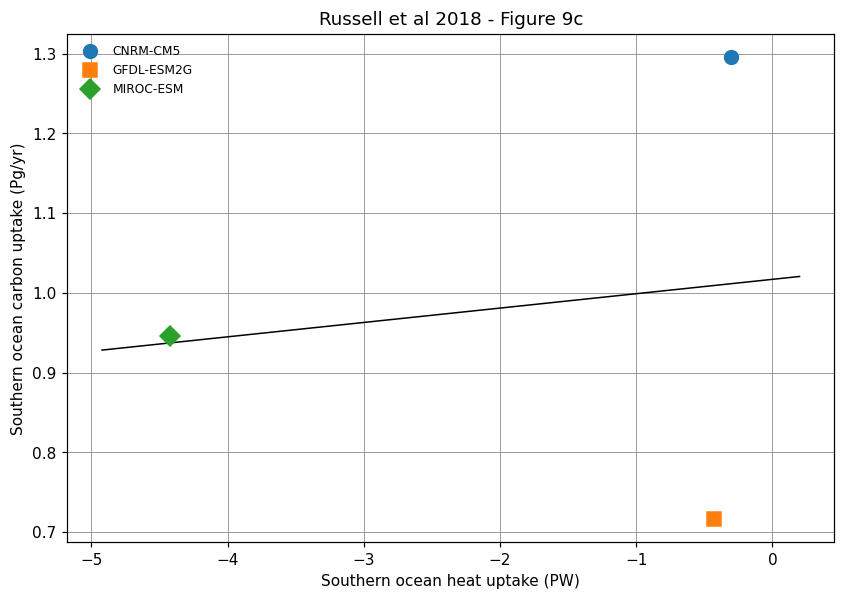

slope = 0.018, intercept = 1.017


In [6]:
CARBON_FACTOR = 0.000031536   # kg s-1 -> Pg yr-1
HEAT_FACTOR = 1.0e-15         # W -> PW

names, xvals, yvals = [], [], []

for name in fgco2_cubes:
    area = np.ma.masked_invalid(areacello_cubes[name].data)

    # integrated heat uptake south of 30S
    hfds = hfds_cubes[name]
    xvals.append(southern_ocean_flux_sum(
        hfds.data, area, lat_1d(hfds), HEAT_FACTOR))

    # integrated carbon uptake south of 30S
    fgco2 = fgco2_cubes[name]
    if has_regular_grid(fgco2):
        carbon_area = ncl_cell_area(lat_1d(fgco2), lon_1d(fgco2),
                                    fgco2.shape)
    else:
        carbon_area = area
    yvals.append(southern_ocean_flux_sum(
        fgco2.data, carbon_area, lat_1d(fgco2), CARBON_FACTOR))
    names.append(name)

xvals, yvals = np.array(xvals), np.array(yvals)

fig, ax = plt.subplots(figsize=(9, 6))

# line of best fit
slope, intercept = np.polyfit(xvals, yvals, 1)
xline = np.linspace(xvals.min() - 0.5, xvals.max() + 0.5, 50)
ax.plot(xline, intercept + slope * xline, color="black", linewidth=1)

for i, (x, y, name) in enumerate(zip(xvals, yvals, names)):
    style = style_for(i)
    ax.plot(x, y, linestyle="none", marker=style["mark"],
            color=style["color"], markersize=9, label=name)

ax.grid(color="grey", linewidth=0.5)
ax.set_xlabel("Southern ocean heat uptake (PW)")
ax.set_ylabel("Southern ocean carbon uptake (Pg/yr)")
ax.set_title("Russell et al 2018 - Figure 9c")
ax.legend(fontsize=8, frameon=False)
plt.show()

print(f"slope = {slope:.3f}, intercept = {intercept:.3f}")

**Figure 9c: Heat uptake vs. carbon uptake:** Net heat uptake south of 30S against the annual-mean integrated carbon
uptake south of 30S, with the line of best fit.